In [1]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit_aer.primitives import Sampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import YahooDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_finance.exceptions import QiskitFinanceError
import numpy as np
import matplotlib.pyplot as plt
import datetime

[*********************100%***********************]  9 of 9 completed


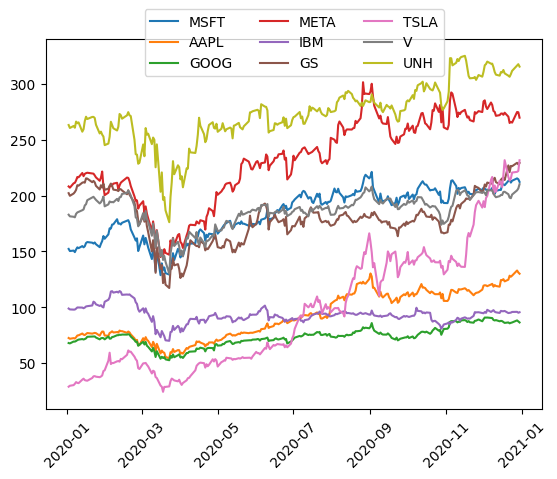

In [12]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ["MSFT", "AAPL", "GOOG", "META", "IBM", "GS", "TSLA", "V", "UNH"]

raw = yf.download(
    tickers,
    start="2020-01-01",
    end="2020-12-31",
    auto_adjust=False
)

prices = raw["Adj Close"]

for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3)
plt.xticks(rotation=45)
plt.show()

In [13]:
returns = prices.pct_change().dropna()

mu = returns.mean().to_numpy()

sigma = returns.cov().to_numpy()

print("Expected returns vector:")
print(mu)

print("\nCovariance matrix:")
print(sigma)

Expected returns vector:
[0.00276907 0.00125223 0.00104221 0.00019794 0.00145423 0.00171069
 0.0099507  0.0011853  0.00091724]

Covariance matrix:
[[0.00086843 0.00053657 0.00060318 0.00043882 0.00065589 0.00068619
  0.00078624 0.00058136 0.00056302]
 [0.00053657 0.00058543 0.00052687 0.0004108  0.0005634  0.00057206
  0.00061225 0.00049203 0.00051431]
 [0.00060318 0.00052687 0.00108846 0.00062343 0.00053104 0.00059186
  0.00073864 0.00067465 0.00067571]
 [0.00043882 0.0004108  0.00062343 0.00066693 0.00037486 0.00045858
  0.00044086 0.00050252 0.00051301]
 [0.00065589 0.0005634  0.00053104 0.00037486 0.00084091 0.00061378
  0.00065926 0.00052238 0.00051567]
 [0.00068619 0.00057206 0.00059186 0.00045858 0.00061378 0.00076919
  0.00079078 0.00058844 0.00058309]
 [0.00078624 0.00061225 0.00073864 0.00044086 0.00065926 0.00079078
  0.00318849 0.00056145 0.000681  ]
 [0.00058136 0.00049203 0.00067465 0.00050252 0.00052238 0.00058844
  0.00056145 0.00092193 0.00061107]
 [0.00056302 0.000514

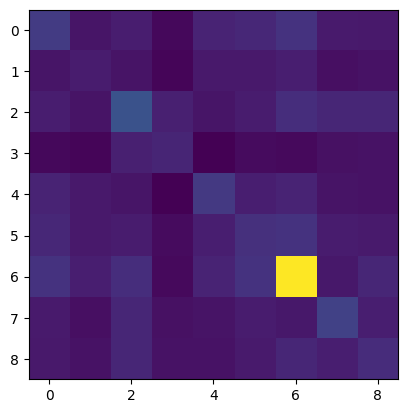

In [14]:
# plot sigma
plt.imshow(sigma, interpolation="nearest")
plt.show()